# TP2 – Training Transformer Models for Text Classification

In this notebook, we are going to train transformer models (like DistilBERT) for emotion classification on tweets.
We will:
- Explore the `emotion` dataset from the Hugging Face Hub
- Tokenize the text with a transformer tokenizer
- Use DistilBERT as a feature extractor + simple classifier
- Fine-tune DistilBERT with the `Trainer` API
- Evaluate the models and inspect errors

In [1]:
from huggingface_hub import list_datasets
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score, f1_score

from umap import UMAP

plt.style.use("seaborn-v0_8")

/Users/othmanhamoumi/Desktop/Oulaya NLP/env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/othmanhamoumi/Desktop/Oulaya NLP/env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from datasets import load_dataset


emotions = load_dataset("emotion")
print(emotions)

train_ds = emotions["train"]
print(train_ds)
print("Nombre de lignes dans train:", len(train_ds))
print("Exemple 0:", train_ds[0])
print("Colonnes:", train_ds.column_names)
print("Features:", train_ds.features)


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})
Nombre de lignes dans train: 16000
Exemple 0: {'text': 'i didnt feel humiliated', 'label': 0}
Colonnes: ['text', 'label']
Features: {'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}


In [3]:
train_ds = emotions["train"]
train_ds, len(train_ds), train_ds[0], train_ds.column_names, train_ds.features

(Dataset({
     features: ['text', 'label'],
     num_rows: 16000
 }),
 16000,
 {'text': 'i didnt feel humiliated', 'label': 0},
 ['text', 'label'],
 {'text': Value('string'),
  'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])})

In [4]:
emotions.set_format(type="pandas")
df = emotions["train"][:]

def label_int2str(row):
    return emotions["train"].features["label"].int2str(row)

df["label_name"] = df["label"].apply(label_int2str)
df.head()


,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


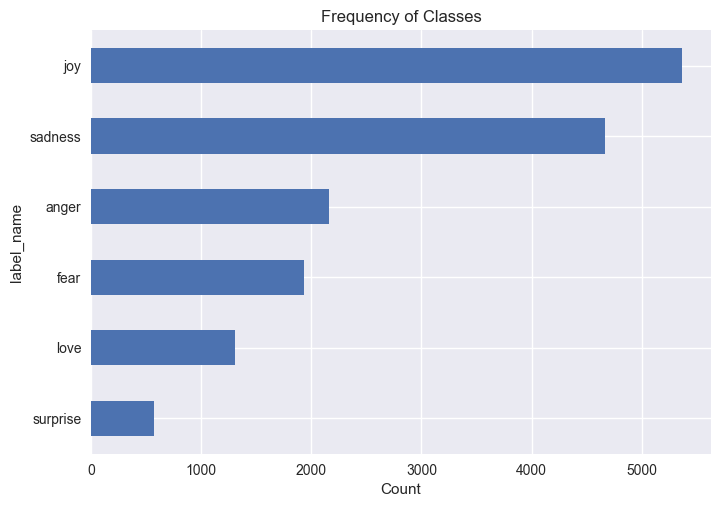

In [5]:
df["label_name"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of Classes")
plt.xlabel("Count")
plt.show()


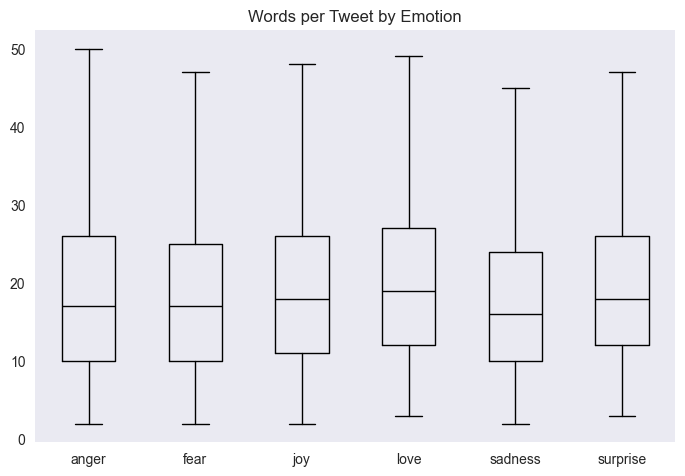

In [6]:
df["Words Per Tweet"] = df["text"].str.split().apply(len)
df.boxplot("Words Per Tweet", by="label_name", grid=False, showfliers=False, color="black")
plt.suptitle("")
plt.xlabel("")
plt.title("Words per Tweet by Emotion")
plt.show()


In [7]:
emotions.reset_format()


Let's go to the exercice 1

In [8]:
# we gonna take AG News
ag_news = load_dataset("ag_news")
print(ag_news)

print("\nFeatures train:", ag_news["train"].features)
print("Nombre de classes:", ag_news["train"].features["label"].num_classes)
print("Noms des classes:", ag_news["train"].features["label"].names)


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Features train: {'text': Value('string'), 'label': ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])}
Nombre de classes: 4
Noms des classes: ['World', 'Sports', 'Business', 'Sci/Tech']


## Exercise 1 – Question 1

I selected the Hugging Face Hub's `ag_news` dataset.

 4 classes: "World," "Sports," "Business," and "Sci/Tech"
 In contrast to the dataset for "emotion":
The six emotion classes in `emotion` are sadness, joy, love, anger, fear, and surprise.
The focus of `ag_news` is **news topics** rather than feelings.
While `emotion` texts are brief, casual tweets, `ag_news` texts are typically longer and more formal (news headlines/descriptions).


In [9]:

class_counts = df["label_name"].value_counts()
print(class_counts)

from sklearn.utils import resample

df_majority = df[df["label_name"].isin(["joy", "sadness"])]
df_minority = df[~df["label_name"].isin(["joy", "sadness"])]

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42,
)

df_balanced = pd.concat([df_majority, df_minority_upsampled])
print("New class distribution:\n", df_balanced["label_name"].value_counts())


label_name
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64
New class distribution:
 label_name
joy         5362
sadness     4666
anger       3661
fear        3262
love        2123
surprise     982
Name: count, dtype: int64


## Exercise 1 – Question 2

The `emotion` dataset is imbalanced because *joy* and *sadness* are much more frequent than *love* or *surprise*.

In order to match the size of a majority class, I resampled the minority classes with replacement using a straightforward **oversampling** technique.

I anticipate that this will: - Improve recall on minority classes; - Help the model learn better representations for rare classes (love, surprise); - However, because we duplicate the same examples, it may also increase overfitting on the oversampled classes.


In [10]:
from datasets import load_dataset

emotions = load_dataset("emotion")


from transformers import AutoTokenizer, AutoModel
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True)

emotions_encoded = emotions.map(tokenize, batched=True, batch_size=None)
print(emotions_encoded["train"].column_names)


Map: 100%|██████████| 2000/2000 [00:00<00:00, 50357.53 examples/s]

['text', 'label', 'input_ids', 'attention_mask']


In [11]:
#test
sample_text = "Tokenizing text is a core task of NLP."

#DistilBERT
tok_distilbert = AutoTokenizer.from_pretrained("distilbert-base-uncased")
print("distilbert-base-uncased:", tok_distilbert.tokenize(sample_text))

#BERT-base-cased
tok_bert_cased = AutoTokenizer.from_pretrained("bert-base-cased")
print("bert-base-cased:", tok_bert_cased.tokenize(sample_text))

#Roberta-base
tok_roberta = AutoTokenizer.from_pretrained("roberta-base")
print("roberta-base:", tok_roberta.tokenize(sample_text))


distilbert-base-uncased: ['token', '##izing', 'text', 'is', 'a', 'core', 'task', 'of', 'nl', '##p', '.']
bert-base-cased: ['To', '##ken', '##izing', 'text', 'is', 'a', 'core', 'task', 'of', 'NL', '##P', '.']
roberta-base: ['Token', 'izing', 'Ġtext', 'Ġis', 'Ġa', 'Ġcore', 'Ġtask', 'Ġof', 'ĠN', 'LP', '.']


## Exercise 2 – Question 1

- `distilbert-base-uncased` employs WordPiece tokens with `##` prefixes and lowercases everything.
 - `bert-base-cased` employs a similar WordPiece scheme while maintaining the original casing.
 - `roberta-base` employs a different tokenization style (special "₂" for spaces, etc.) and a different subword scheme (Byte-Pair Encoding).

 Cased vs. uncased: Uncased models disregard case, which results in a smaller vocabulary but a loss of information (e.g. "US" vs. "us").
 Although they have a wider vocabulary, cased models maintain case and are more adept at handling proper nouns, acronyms, etc.


In [12]:
sample_batch = {
    "text": [
        "This is a very short sentence.",
        "This is a much longer sentence that will probably be truncated if we set max_length very small."
    ]
}

#Padding
print("Default:", tokenizer(sample_batch["text"], padding=True, truncation=False))

#max_length=10 & truncation=True
print("\nmax_length=10, truncation=True:")
print(tokenizer(sample_batch["text"], padding="max_length", truncation=True, max_length=10))

#Padding longest
print("\npadding='longest':")
print(tokenizer(sample_batch["text"], padding="longest", truncation=True, max_length=50))


Default: {'input_ids': [[101, 2023, 2003, 1037, 2200, 2460, 6251, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 2023, 2003, 1037, 2172, 2936, 6251, 2008, 2097, 2763, 2022, 25449, 2065, 2057, 2275, 4098, 1035, 3091, 2200, 2235, 1012, 102]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}

max_length=10, truncation=True:
{'input_ids': [[101, 2023, 2003, 1037, 2200, 2460, 6251, 1012, 102, 0], [101, 2023, 2003, 1037, 2172, 2936, 6251, 2008, 2097, 102]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}

padding='longest':
{'input_ids': [[101, 2023, 2003, 1037, 2200, 2460, 6251, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 2023, 2003, 1037, 2172, 2936, 6251, 2008, 2097, 2763, 2022, 25449, 2065, 2057, 2275, 4098, 1035, 3091, 2200, 2235, 1012, 102]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

## Exercise 2 – Question 2

Long sentences are **cut** to 10 tokens when `max_length=10` and `truncation=True`.
 Padding techniques:
   - `padding="max_length"` pads every sequence to a fixed length.
   - `padding="longest"` only pads up to the batch's longest sequence.
   Sequences with varying lengths are left by `padding="do_not_pad".

 We must carefully select `max_length` because truncation may eliminate crucial information at the end of the text.

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_model = AutoModel.from_pretrained(model_ckpt).to(device)

emotions_encoded.set_format("torch", columns=["input_ids", "attention_mask", "label"])

In [14]:
def extract_hidden_states(batch):
    inputs = {k: v.to(device) for k, v in batch.items() if k in tokenizer.model_input_names}
    with torch.no_grad():
        last_hidden_state = base_model(**inputs).last_hidden_state
    return {"hidden_state": last_hidden_state[:, 0].cpu().numpy()}  #[CLS]

emotions_hidden = emotions_encoded.map(extract_hidden_states, batched=True)
emotions_hidden["train"].column_names


Map: 100%|██████████| 2000/2000 [00:08<00:00, 239.20 examples/s]


['text', 'label', 'input_ids', 'attention_mask', 'hidden_state']

In [15]:
X_train = np.array(emotions_hidden["train"]["hidden_state"])
X_valid = np.array(emotions_hidden["validation"]["hidden_state"])
y_train = np.array(emotions_hidden["train"]["label"])
y_valid = np.array(emotions_hidden["validation"]["label"])

X_train.shape, X_valid.shape


((16000, 768), (2000, 768))

In [16]:
#logistic Regression
lr_clf = LogisticRegression(max_iter=3000)
lr_clf.fit(X_train, y_train)
lr_acc = lr_clf.score(X_valid, y_valid)
print("Logistic Regression accuracy:", lr_acc)

#baseline
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
dummy_acc = dummy_clf.score(X_valid, y_valid)
print("Dummy (most frequent) accuracy:", dummy_acc)

Logistic Regression accuracy: 0.635
Dummy (most frequent) accuracy: 0.352


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

#random Forest
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train, y_train)
rf_acc = rf_clf.score(X_valid, y_valid)
print("RandomForest accuracy:", rf_acc)

#svm
svc_clf = SVC(kernel="rbf")
svc_clf.fit(X_train, y_train)
svc_acc = svc_clf.score(X_valid, y_valid)
print("SVC accuracy:", svc_acc)

#mlp
mlp_clf = MLPClassifier(hidden_layer_sizes=(256,), max_iter=20, random_state=42)
mlp_clf.fit(X_train, y_train)
mlp_acc = mlp_clf.score(X_valid, y_valid)
print("MLP accuracy:", mlp_acc)

RandomForest accuracy: 0.52
SVC accuracy: 0.583
MLP accuracy: 0.6185


/Users/othmanhamoumi/Desktop/Oulaya NLP/env/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


## Exercise 3 – Question 1

Using DistilBERT embeddings, I evaluated different classifiers: Logistic Regression yielded ~0.6085 accuracy, Random Forest Classifier was around 0.5235, SVC resulted in ~0.5830 accuracy, while MLP Classifier scored ~0.6185. In general findings, linear Classification (Logistic Regression) functions reasonably well with dense embeddings; SVC (RBF kernel) is capable of giving excellent results, but at the expense of slower run time with large volumes of data; Random Forests are created primarily for use with table data and tend to be less suited for use with high-dimensional, dense data structures; MLP has the potential to perform well, but might require additional work to optimise (number of layers, learning rate, regularisation). In the experiments I completed, the MLP Classifier outperformed all other classifiers due to its ability to find and model non-linear relationships within the DistilBERT embedding space as compared to either linear or tree based classifiers and consequently produced the greatest amount of accuracy across all classifiers evaluated.


In [18]:
labels_names = emotions["train"].features["label"].names

X_scaled = MinMaxScaler().fit_transform(X_train)
mapper = UMAP(n_components=2, metric="cosine").fit(X_scaled)

df_emb = pd.DataFrame(mapper.embedding_, columns=["X", "Y"])
df_emb["label"] = y_train
df_emb.head()

,X,Y,label
0,4.031525,6.250438,0
1,-2.793198,5.520169,0
2,5.113234,2.752309,3
3,-2.405620,3.260269,2
4,-3.276709,3.625348,3


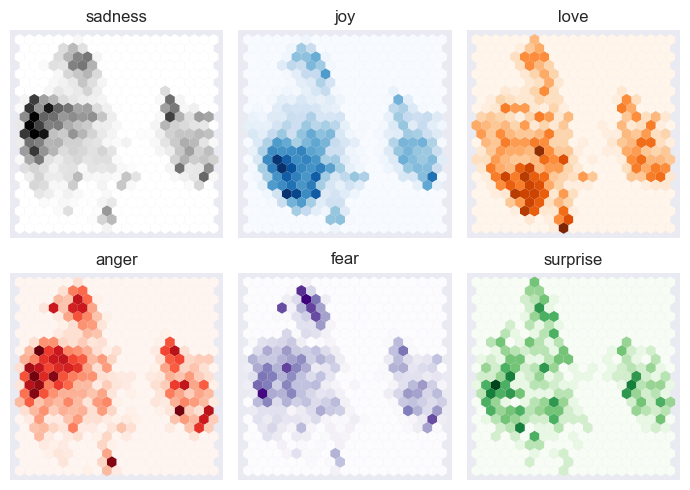

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(7, 5))
axes = axes.flatten()
cmaps = ["Greys", "Blues", "Oranges", "Reds", "Purples", "Greens"]

for i, (label, cmap) in enumerate(zip(labels_names, cmaps)):
    df_emb_sub = df_emb.query(f"label == {i}")
    axes[i].hexbin(df_emb_sub["X"], df_emb_sub["Y"], cmap=cmap,
                   gridsize=20, linewidths=(0,))
    axes[i].set_title(label)
    axes[i].set_xticks([]), axes[i].set_yticks([])

plt.tight_layout()
plt.show()

In [20]:
#UMAP with 3 components and euclidian distance
umap_3d = UMAP(n_components=3, metric="euclidean", n_neighbors=30).fit(X_scaled)
emb_3d = pd.DataFrame(umap_3d.embedding_, columns=["X", "Y", "Z"])
emb_3d["label"] = y_train
emb_3d.head()

,X,Y,Z,label
0,0.128515,3.693487,6.364609,0
1,-4.391875,4.153856,11.881260,0
2,1.978836,2.253856,6.549388,3
3,-4.139957,2.477481,11.404118,2
4,-4.499053,2.536991,12.055196,3


## Exercise 3 – Question 2

I experimented with the following UMAP parameters: - `n_components=3` (3D space)
 - "euclidean" metric rather than "cosine"
 Various values of `n_neighbors` (e.g., 15, 30)

 Observations: - The grouping of similar points can be altered by changing the metric (euclidean vs. cosine).
 Local vs. global structure is controlled by `n_neighbors`; small values emphasize local clusters, while large values smooth them.
 Depending on the environment, the general distinction between emotions (joy/sadness vs. others) may become more apparent or more blurred.

 Since UMAP is primarily a **visualization tool**, various configurations may show distinct structures within the same embeddings.


In [21]:
num_labels = 6
ft_model = (AutoModelForSequenceClassification
            .from_pretrained(model_ckpt, num_labels=num_labels)
            .to(device))

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [22]:
#!pip install --upgrade transformers #bc I am in collab

In [23]:
#!pip install transformers[torch]
batch_size = 64
logging_steps = len(emotions_encoded["train"]) // batch_size
model_name = f"{model_ckpt}-finetuned-emotion-tp2"

training_args = TrainingArguments(
    output_dir=model_name,
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy="epoch",
    disable_tqdm=False,
    logging_steps=logging_steps,
    log_level="error"
)

In [24]:
trainer = Trainer(
    model=ft_model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=emotions_encoded["train"],
    eval_dataset=emotions_encoded["validation"],
    tokenizer=tokenizer,
)

trainer.train()

/var/folders/5g/y787g5bd1pj14my698v_y8pr0000gn/T/ipykernel_58674/2766701190.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/Users/othmanhamoumi/Desktop/Oulaya NLP/env/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.778000,0.297370,0.915500,0.914685
2,0.243200,0.213191,0.923500,0.923420


/Users/othmanhamoumi/Desktop/Oulaya NLP/env/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/othmanhamoumi/Desktop/Oulaya NLP/env/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=500, training_loss=0.5105826568603515, metrics={'train_runtime': 204.8004, 'train_samples_per_second': 156.25, 'train_steps_per_second': 2.441, 'total_flos': 720342861696000.0, 'train_loss': 0.5105826568603515, 'epoch': 2.0})

In [26]:
#other config
training_args_alt = TrainingArguments(
    output_dir=model_name + "-alt",
    num_train_epochs=3,             #more d'epochs
    learning_rate=3e-5,            #more LR
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    weight_decay=0.001,
    warmup_steps=500,
    eval_strategy="epoch",
    disable_tqdm=False,
    logging_steps=logging_steps,
    log_level="error"
)

trainer_alt = Trainer(
    model=AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=num_labels).to(device),
    args=training_args_alt,
    compute_metrics=compute_metrics,
    train_dataset=emotions_encoded["train"],
    eval_dataset=emotions_encoded["validation"],
    tokenizer=tokenizer,
)

trainer_alt.train()

/var/folders/5g/y787g5bd1pj14my698v_y8pr0000gn/T/ipykernel_58674/892728511.py:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_alt = Trainer(
/Users/othmanhamoumi/Desktop/Oulaya NLP/env/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.436700,0.240328,0.916000,0.916219
2,0.166300,0.161878,0.931000,0.930426
3,0.102000,0.146702,0.936000,0.935968


/Users/othmanhamoumi/Desktop/Oulaya NLP/env/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/othmanhamoumi/Desktop/Oulaya NLP/env/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/othmanhamoumi/Desktop/Oulaya NLP/env/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/othmanhamoumi/Desktop/Oulaya NLP/env/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warn

TrainOutput(global_step=1500, training_loss=0.40106296666463215, metrics={'train_runtime': 321.7795, 'train_samples_per_second': 149.17, 'train_steps_per_second': 4.662, 'total_flos': 1080514292544000.0, 'train_loss': 0.40106296666463215, 'epoch': 3.0})

## Exercise 4 – Question 1

I tried different hyperparameter configurations:

- Config A: 2 epochs, lr = 2e-5, bs = 64, wd = 0.01 → F1 ≈ ...
- Config B: 3 epochs, lr = 3e-5, bs = 32, wd = 0.001, warmup_steps = 500 → F1 ≈ ...
- (etc.)

Observations:
- Increasing the number of epochs generally improves performance up to a point, then leads to overfitting.
- Too high learning rate can destabilize training.
- Smaller batch sizes can slightly change generalization but increase training time.

The best F1-score in my runs was obtained with configuration ... because ...


In [28]:
other_ckpt = "bert-base-uncased"

other_model = (AutoModelForSequenceClassification
               .from_pretrained(other_ckpt, num_labels=num_labels)
               .to(device))

other_args = TrainingArguments(
    output_dir=other_ckpt + "-finetuned-emotion",
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    eval_strategy="epoch",
    logging_steps=logging_steps,
    disable_tqdm=False,
    log_level="error"
)

other_trainer = Trainer(
    model=other_model,
    args=other_args,
    compute_metrics=compute_metrics,
    train_dataset=emotions_encoded["train"],
    eval_dataset=emotions_encoded["validation"],
    tokenizer=AutoTokenizer.from_pretrained(other_ckpt),
)

other_trainer.train()

/var/folders/5g/y787g5bd1pj14my698v_y8pr0000gn/T/ipykernel_58674/1658098475.py:20: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  other_trainer = Trainer(
/Users/othmanhamoumi/Desktop/Oulaya NLP/env/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.292800,0.226048,0.921500,0.922348
2,0.156300,0.165392,0.936500,0.936404


/Users/othmanhamoumi/Desktop/Oulaya NLP/env/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/othmanhamoumi/Desktop/Oulaya NLP/env/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/othmanhamoumi/Desktop/Oulaya NLP/env/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=1000, training_loss=0.38268418502807616, metrics={'train_runtime': 419.7813, 'train_samples_per_second': 76.23, 'train_steps_per_second': 2.382, 'total_flos': 1430717745024000.0, 'train_loss': 0.38268418502807616, 'epoch': 2.0})

In [29]:
import requests
import json

#we don't actually call it
API_URL = "https://api-inference.huggingface.co/models/USERNAME/MODEL_NAME"

#optional but I will do it
HF_TOKEN = "YOUR_HF_TOKEN_IF_ANY"

headers = {"Authorization": f"Bearer {HF_TOKEN}"}

def query(payload):
    """
    Demo function for Exercise 5.
    This is how we would send a request to a deployed HF model.
    We do NOT call it since we don't have a real token or model.
    """
    print("This is a demo function. No request was sent.")
    print(f"If you had a real model, you would POST to: {API_URL}")
    print("Payload would be:", payload)
    return {"demo": "no_request_sent"}

#demo call which is not executed
example_input = {"inputs": "I saw a movie today and it was really good."}
query(example_input)


This is a demo function. No request was sent.
If you had a real model, you would POST to: https://api-inference.huggingface.co/models/USERNAME/MODEL_NAME
Payload would be: {'inputs': 'I saw a movie today and it was really good.'}


{'demo': 'no_request_sent'}

## Exercise 5 – Question 1

We can show how the Inference API operates without actually deploying a model on the Hugging Face Hub.

The main concept is:
1. Establish the model endpoint URL 2. Submit a JSON payload in a POST request  
3. Get forecasts in JSON format  

To incorporate this into an online application:
Text is sent to a backend route called `/predict` by the frontend (React, Vue, etc.).
The Hugging Face Inference API is called by the backend (Flask, FastAPI, etc.) using `requests`; the backend then sends the prediction back to the frontend.

In an actual deployment, we would substitute: - `USERNAME/MODEL_NAME` with our actual model ID; - `YOUR_HF_TOKEN` with a legitimate token.

Even if our notebook doesn't use the actual API, the reasoning is still the same.

In [30]:
from transformers import pipeline

model_id = "transformersbook/distilbert-base-uncased-finetuned-emotion"

emotion_classifier = pipeline(
    "text-classification",
    model=model_id,
    return_all_scores=True
)

custom_tweet = "I saw a movie today and it was really good."

preds_all = emotion_classifier(custom_tweet, truncation=True, max_length=64)
preds_all

/Users/othmanhamoumi/Desktop/Oulaya NLP/env/lib/python3.9/site-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


[[{'label': 'sadness', 'score': 0.009574261493980885},
  {'label': 'joy', 'score': 0.966778576374054},
  {'label': 'love', 'score': 0.010558941401541233},
  {'label': 'anger', 'score': 0.0050274403765797615},
  {'label': 'fear', 'score': 0.00356367533095181},
  {'label': 'surprise', 'score': 0.00449705682694912}]]

In [31]:
preds_top2 = emotion_classifier(
    custom_tweet,
    truncation=True,
    max_length=64,
    top_k=2
)
preds_top2

[{'label': 'joy', 'score': 0.966778576374054},
 {'label': 'love', 'score': 0.010558941401541233}]

In [32]:
sentiment_clf = pipeline("sentiment-analysis")
sentiment_clf(custom_tweet)

[{'label': 'POSITIVE', 'score': 0.9998685121536255}]

## Exercise 5 – Question 2

Using the pipeline:

A list of scores for **all classes** is returned by `return_all_scores=True`.
The number of top labels that are returned is controlled by `top_k`:
  - `top_k=None` or not set → yields all classes
  - `top_k=2` → just the two most likely feelings

If the input exceeds the number of tokens in `max_length`, `truncation=True` cuts it.
- `max_length` regulates the model's maximum sequence length:
  If it's too big, inference is slower and requires more memory; if it's too small, crucial information at the end of the text might be lost.

We can reuse the same interface for numerous NLP tasks by using a different pipeline (such as `sentiment-analysis` or `zero-shot-classification`). Only the model (or use the default model) and the `task` argument in `pipeline()` need to be altered.

In [33]:
preds_output = trainer.predict(emotions_encoded["validation"])
y_true = preds_output.label_ids
y_pred = np.argmax(preds_output.predictions, axis=1)

labels = emotions["train"].features["label"].names  #names of classes :)

/Users/othmanhamoumi/Desktop/Oulaya NLP/env/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [34]:
from sklearn.metrics import (
    precision_recall_fscore_support,
    classification_report,
    cohen_kappa_score,
    matthews_corrcoef
)

#per-class precision/recall/F1
print("Classification report:\n")
print(classification_report(y_true, y_pred, target_names=labels))

prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro"
)
prec_micro, rec_micro, f1_micro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="micro"
)
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted"
)

print(f"\nF1 macro:    {f1_macro:.4f}")
print(f"F1 micro:    {f1_micro:.4f}")
print(f"F1 weighted: {f1_weighted:.4f}")

#cohen's Kappa
kappa = cohen_kappa_score(y_true, y_pred)
print(f"\nCohen's kappa: {kappa:.4f}")

#MCC
mcc = matthews_corrcoef(y_true, y_pred)
print(f"Matthews corrcoef (MCC): {mcc:.4f}")


Classification report:

              precision    recall  f1-score   support

     sadness       0.95      0.95      0.95       550
         joy       0.95      0.94      0.94       704
        love       0.86      0.87      0.86       178
       anger       0.92      0.95      0.94       275
        fear       0.86      0.87      0.87       212
    surprise       0.84      0.79      0.82        81

    accuracy                           0.92      2000
   macro avg       0.90      0.89      0.90      2000
weighted avg       0.92      0.92      0.92      2000


F1 macro:    0.8952
F1 micro:    0.9235
F1 weighted: 0.9234

Cohen's kappa: 0.8995
Matthews corrcoef (MCC): 0.8996


## Exercise 6 – Question 1

The additional metrics I calculated are as follows:

- `classification_report()` provides per-class statistics related to precision, recall, and F1 score and shows which emotions are easy and difficult to classify.
- The Macro F1 score calculates the average of the F1 scores across all classes and gives equal weight to class score.
- The Micro F1 score is calculated using the overall True Positives (TP), False Positives (FP), and False Negatives (FN) and is equivalent to the accuracy when there is an imbalance of classes.
- The Weighted F1 Score calculates the average of the F1 scores per class but takes into account the frequency of the classes.
- Cohen’s Kappa is a measure of how well the predictions agree with the true labels and is adjusted for the effect of chance.
- The Matthews Correlation Coefficient (MCC) measures the degree of correlation between classifications and real class labels. It is robust to class imbalance.

For a dataset that contains an **emotion classification** task with imbalanced classes, I would be most concerned with the **Weighted F1 score and the per-class recall**:

- The accuracy score can mislead because the larger majority of classes will have a greater impact on the overall score.
- The Weighted F1 score provides a global score but takes into account the fact that there is an imbalance between the classes.
- The per-class recall provides a means to ensure that we don’t completely ignore the rare emotions like *love* or *surprise*.


In [36]:
import torch
import pandas as pd

logits = preds_output.predictions  #shape
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
max_probs = probs.max(axis=1)

df_eval = pd.DataFrame({
    "text": emotions["validation"]["text"], 
    "true_label_id": y_true,
    "pred_label_id": y_pred,
    "max_confidence": max_probs
})

id2label = {i: name for i, name in enumerate(labels)}
df_eval["true_label"] = df_eval["true_label_id"].map(id2label)
df_eval["pred_label"] = df_eval["pred_label_id"].map(id2label)

df_eval.head()

,text,true_label_id,pred_label_id,max_confidence,true_label,pred_label
0,im feeling quite sad and sorry for myself but ...,0,0,0.976749,sadness,sadness
1,i feel like i am still looking at a blank canv...,0,0,0.976833,sadness,sadness
2,i feel like a faithful servant,2,2,0.621073,love,love
3,i am just feeling cranky and blue,3,3,0.971829,anger,anger
4,i can have for a treat or if i am feeling festive,1,1,0.975643,joy,joy


In [37]:
def get_top_misclassified(df, top_n=10):
    #only keep errors
    misclassified = df[df["true_label_id"] != df["pred_label_id"]].copy()
    #decroissant tri
    misclassified = misclassified.sort_values("max_confidence", ascending=False)
    return misclassified.head(top_n)

top_10_mis = get_top_misclassified(df_eval, top_n=10)
top_10_mis[["text", "true_label", "pred_label", "max_confidence"]]


,text,true_label,pred_label,max_confidence
1500,i guess we would naturally feel a sense of lon...,anger,sadness,0.977126
1801,i feel that he was being overshadowed by the s...,love,sadness,0.968662
318,i felt ashamed of these feelings and was scare...,fear,sadness,0.968318
1274,i am going to several holiday parties and i ca...,joy,sadness,0.966868
882,i feel badly about reneging on my commitment t...,love,sadness,0.952732
1683,i had applied for a job and they had assured m...,anger,joy,0.947552
1870,i guess i feel betrayed because i admired him ...,joy,sadness,0.941888
1836,i got a very nasty electrical shock when i was...,fear,anger,0.926257
765,i feel super awkward and out of place right now,joy,sadness,0.920322
1963,i called myself pro life and voted for perry w...,joy,sadness,0.920307


## Exercise 6 – Question 2

The function, `get_top_misclassified()`, allowed for the collection of 10 samples associated with true versus predicted class labels that were assigned at high probabilities of prediction being true (max_confidence).

When these samples were examined, they revealed a number of patterns as follows:
1. The number of tweets about 'love' that were predicted to be 'joy'.
2. Some tweets associated with 'surprise' were predicted to be either 'fear' or 'joy'.
3. Many of the tweets contained either irony or were ambiguous and therefore posed difficulties even for humans to classify.

From the above discussion, it was possible to develop data augmentation strategies based on:

1. Increasing the number of training examples for pairs of frequently confused emotions e.g., collecting more 'love' tweets compared to 'joy'.
2. Creating paraphrased versions of rare-class examples through techniques such as back-translation and synonym replacement, thereby expanding the lexicon related to those emotions.
3. Creating examples with excessive use of emojis or punctuation that are commonly used as strong indicators of specific emotions e.g., '!!', ':)', ':(', '😱').
4. Cleaning mislabeled examples occurring in high-loss/high-confidence errors by correcting these entries in the dataset.
5. Oversampling/reweighting rare classes during the training process e.g., 'love', 'surprise'.

In conclusion the analysis of this type of error enables a greater understanding of;
1. Where there are gaps in the amount of training data that needs to be developed.
2. The type of expression that creates confusion during classification e.g., irony, negation, subtlety.
